In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torch.nn.functional as F
import torch.nn as nn 
from PIL import Image

import lpips

from diffusers.models import AutoencoderKL

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, RocCurveDisplay
import seaborn as sns

from tqdm import tqdm
import copy

In [4]:
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM libre: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

VRAM libre: 25.3 GB


In [5]:
class SafeSubset(Dataset):
    """
    Envuelve cualquier Subset (o Dataset) y garantiza que cada tensor
    devuelto es contiguo en memoria propia, evitando el error
    'Trying to resize storage that is not resizable'.
    """
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return img.clone().contiguous(), label


In [ ]:
test_dir = '/workspace/dataset/test/'
train_dir = '/workspace/dataset/train/'

IMG_SIZE   = 256
BATCH_SIZE = 16
VAL_SPLIT  = 0.2
SEED       = 42
N_SAMPLES  = 1024   # tamaño de los subsets pequeños para pruebas rápidas
NITS     = 50
LR        = 5e-5
PATIENCE = 5

# Solo resize y normalización — para val y test (sin augmentation)
resize_only = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Resize + augmentation — solo para train
resize_augment = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=36),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomAutocontrast(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
train_ds_augmented = datasets.ImageFolder(root=train_dir, transform=resize_augment)
train_ds_clean     = datasets.ImageFolder(root=train_dir, transform=resize_only)
test_ds            = datasets.ImageFolder(root=test_dir,  transform=resize_only)

print(f"Clases detectadas : {train_ds_augmented.classes}")
print(f"class_to_idx      : {train_ds_augmented.class_to_idx}")

n_total = len(train_ds_augmented)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val], generator=generator
)

real_label = train_ds_augmented.class_to_idx['real']

real_train_indices = [
    i for i in train_indices.indices
    if train_ds_augmented.samples[i][1] == real_label
]
real_val_indices = [
    i for i in val_indices.indices
    if train_ds_clean.samples[i][1] == real_label
]

train_dataset = Subset(train_ds_augmented, train_indices.indices)
val_dataset   = Subset(train_ds_clean,     val_indices.indices)

train_real_dataset = Subset(train_ds_augmented, real_train_indices)
val_real_dataset   = Subset(train_ds_clean,     real_val_indices)

print(f"Tamaños — train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_ds)}")
print(f"Tamaños reales — train_real: {len(train_real_dataset)}, val_real: {len(val_real_dataset)}")


Clases detectadas : ['fake', 'real']
class_to_idx      : {'fake': 0, 'real': 1}
Tamaños — train: 38297, val: 9574, test: 11964
Tamaños reales — train_real: 19208, val_real: 4781


In [8]:
train_real_dataset = SafeSubset(train_real_dataset)
val_real_dataset = SafeSubset(val_real_dataset)

etiquetas = test_ds.classes
etiqueta_a_categoria = test_ds.class_to_idx

In [ ]:
img, lbl = train_real_dataset[15]
print(f"Shape imagen    : {img.shape}")
print(f"Rango píxeles   : {img.min():.2f} a {img.max():.2f}")
print(f"Categoría       : {lbl} ({train_ds_augmented.classes[lbl]})")
print(f"Clases → índice : {test_ds.class_to_idx}")


Shape imagen    : torch.Size([3, 256, 256])
Rango píxeles   : -1.00 a 1.00
Categoría       : 1 (real)
Clases → índice : {'fake': 0, 'real': 1}


In [ ]:
dataloader_test = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

dataloader_train_real = DataLoader(
    train_real_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

dataloader_val_real = DataLoader(
    val_real_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2,
    persistent_workers=True
)

print(f"Batches — test: {len(dataloader_test)}, test_small: {len(dataloader_test)}")
print(f"Batches — train_real: {len(dataloader_train_real)}, train_real_small: {len(dataloader_train_real)}")
print(f"Batches — val_real: {len(dataloader_val_real)}, val_real_small: {len(dataloader_val_real)}")

Batches — test: 748, test_small: 748
Batches — train_real: 1201, train_real_small: 1201
Batches — val_real: 299, val_real_small: 299


In [12]:
from diffusers.models import AutoencoderKL
from torchsummary import summary

vae = AutoencoderKL.from_pretrained("REPA-E/e2e-invae-hf")
vae.enable_gradient_checkpointing()
vae.eval().to("cuda")

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0-1): 2 x DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (2): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
        

In [ ]:
def vae_loss_diffusers(recon, x, posterior, beta=1.0):
    """
    recon     : imagen reconstruida [B, 3, H, W]
    x         : imagen original     [B, 3, H, W]
    posterior : DiagonalGaussianDistribution devuelto por vae.encode()
    beta      : peso de la KL (KL annealing)
    """

    recon_loss = F.mse_loss(recon, x, reduction='mean')
    return recon_loss

In [ ]:
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

for param in vae.encoder.parameters():
    param.requires_grad = False

for param in vae.decoder.parameters():
    param.requires_grad = True

optimizador = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vae.parameters()),
    lr=LR
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

mejor_perdida_val = float('inf')
epocas_sin_mejora = 0
mejores_pesos     = None

perdidas_train = []
perdidas_val   = []

os.makedirs('./checkpoints', exist_ok=True)

for epoch in range(NITS):
    beta = epoch / max(NITS - 1, 1)

    vae.train()
    acumulador_train = 0.0

    for imgs, _ in tqdm(dataloader_train_real, desc=f"Epoch {epoch+1}/{NITS} [train]"):
        imgs = imgs.to(device)

        posterior = vae.encode(imgs).latent_dist
        z         = posterior.sample()
        recon     = vae.decode(z).sample

        loss = vae_loss_diffusers(recon, imgs, posterior, beta=beta)

        optimizador.zero_grad()
        loss.backward()
        optimizador.step()

        acumulador_train += loss.item() * imgs.size(0)

    epoch_loss_train = acumulador_train / len(dataloader_train_real.dataset)
    perdidas_train.append(epoch_loss_train)

    vae.eval()
    acumulador_val = 0.0

    with torch.no_grad():
        for imgs, _ in tqdm(dataloader_val_real, desc=f"Epoch {epoch+1}/{NITS} [val]"):
            imgs = imgs.to(device)

            posterior = vae.encode(imgs).latent_dist
            z         = posterior.mode()
            recon     = vae.decode(z).sample

            loss = vae_loss_diffusers(recon, imgs, posterior, beta=beta)

            acumulador_val += loss.item() * imgs.size(0)

    epoch_loss_val = acumulador_val / len(dataloader_val_real.dataset)
    perdidas_val.append(epoch_loss_val)

    print(f"Epoch [{epoch+1}/{NITS}] — train: {epoch_loss_train:.6f} | val: {epoch_loss_val:.6f} | beta: {beta:.2f} | lr: {optimizador.param_groups[0]['lr']:.2e}")

    scheduler.step(epoch_loss_val)

    if epoch_loss_val < mejor_perdida_val:
        mejor_perdida_val = epoch_loss_val
        epocas_sin_mejora = 0

        torch.save({
            'epoch'           : epoch,
            'model_state_dict': vae.state_dict(),
            'optim_state_dict': optimizador.state_dict(),
            'sched_state_dict': scheduler.state_dict(),
            'val_loss'        : mejor_perdida_val,
        }, '/workspace/mejor_modelo_vae_pretrained_ft.pth')

        mejores_pesos = copy.deepcopy(vae.state_dict())
        print(f"  → Mejor modelo guardado (val: {mejor_perdida_val:.6f})")

    else:
        epocas_sin_mejora += 1
        print(f"  → Sin mejora ({epocas_sin_mejora}/{PATIENCE})")

    if epocas_sin_mejora >= PATIENCE:
        print(f"\nEarlyStopping activado en epoch {epoch+1}. Mejor val_loss: {mejor_perdida_val:.6f}")
        vae.load_state_dict(mejores_pesos)
        break

print(f"\nEntrenamiento finalizado. Mejor val_loss: {mejor_perdida_val:.6f}")

In [14]:
checkpoint = torch.load('/workspace/mejor_modelo_vae_pretrained_ft.pth')
vae.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
def normalizar(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def error_latente_robusto(mu, mu_real_media, mu_real_std, device):
    """
    Mide cuánto se aleja mu de la distribución aprendida de imágenes reales.
    Equivale a una distancia de Mahalanobis simplificada asumiendo
    independencia entre dimensiones.
    """
    mu_flat = mu.view(mu.size(0), -1)

    mu_media = mu_real_media.to(device)
    mu_std   = mu_real_std.to(device).clamp(min=1e-6)  # evitar división por cero

    distancia = ((mu_flat - mu_media) ** 2 / mu_std ** 2).mean(dim=1)  # [B]
    return distancia

In [35]:
vae.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn_vgg = lpips.LPIPS(net='vgg').to(device)

y_true = []
mus_reales = []

with torch.no_grad():
    for imgs, _ in tqdm(dataloader_train_real):
        imgs = imgs.to(device)
        mu = vae.encode(imgs).latent_dist.mean
        mus_reales.append(mu.view(mu.size(0), -1).cpu())

mus_reales = torch.cat(mus_reales, dim=0)

mu_real_media = mus_reales.mean(dim=0)
mu_real_std   = mus_reales.std(dim=0)

print(f"Distribución real en latente: media={mu_real_media.mean():.4f}, std={mu_real_std.mean():.4f}")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


100%|██████████| 1201/1201 [01:28<00:00, 13.59it/s]


Distribución real en latente: media=-0.0952, std=3.0667


In [ ]:
vae.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

y_true = []
errores_latent_rob_list = []
errores_pixel = []

with torch.no_grad():
    for img, label in tqdm(dataloader_test):
        img = img.to(device)

        posterior = vae.encode(img).latent_dist
        mu        = posterior.mean
        
        error_latente_rob = error_latente_robusto(mu, mu_real_media, mu_real_std, device)
        pred = vae.decode(mu).sample

        mse         = F.mse_loss(pred, img, reduction='none').mean(dim=[1,2,3])
        l1          = F.l1_loss(pred, img, reduction='none').mean(dim=[1,2,3])

        error_pixel = mse
        
        errores_latent_rob_list.extend(error_latente_rob.cpu().tolist())
        errores_pixel.extend(error_pixel.cpu().tolist())
        y_true.extend(label.tolist())

100%|██████████| 748/748 [02:30<00:00,  4.97it/s]


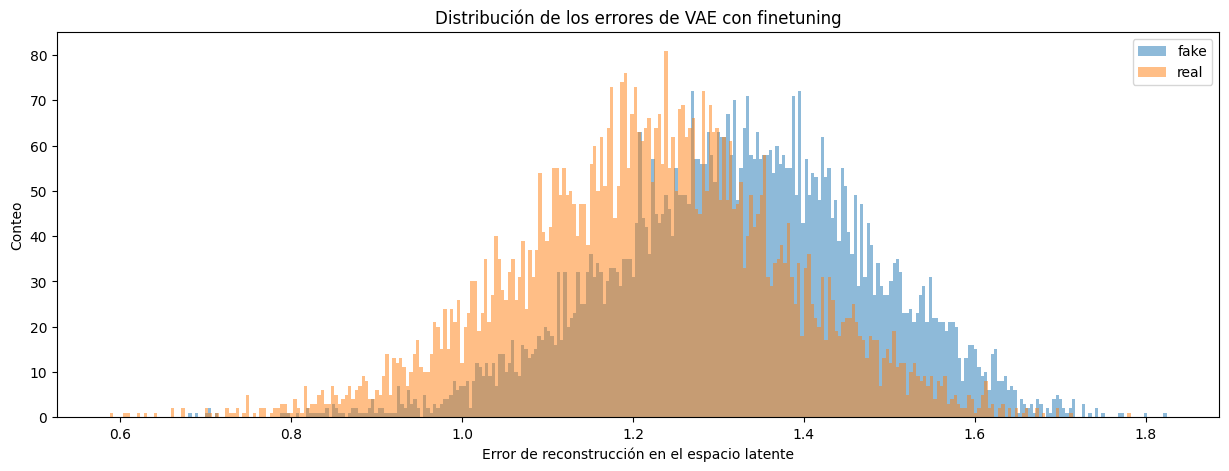

In [71]:
errores_latent_rob_list = np.array(errores_latent_rob_list)
y_true = np.array(y_true)

plt.figure(figsize=(15, 5))

plt.hist(errores_latent_rob_list[y_true == 0], bins=300, alpha=0.5, label="fake")
plt.hist(errores_latent_rob_list[y_true == 1], bins=300, alpha=0.5, label="real")
plt.legend()
plt.title("Distribución de los errores de VAE con finetuning")
plt.xlabel("Error de reconstrucción en el espacio latente")
plt.ylabel("Conteo");
plt.savefig('/workspace/imagenes_metricas_vae/distribucion_errores_vae_ft_final.png', dpi=150, bbox_inches='tight')
plt.show()

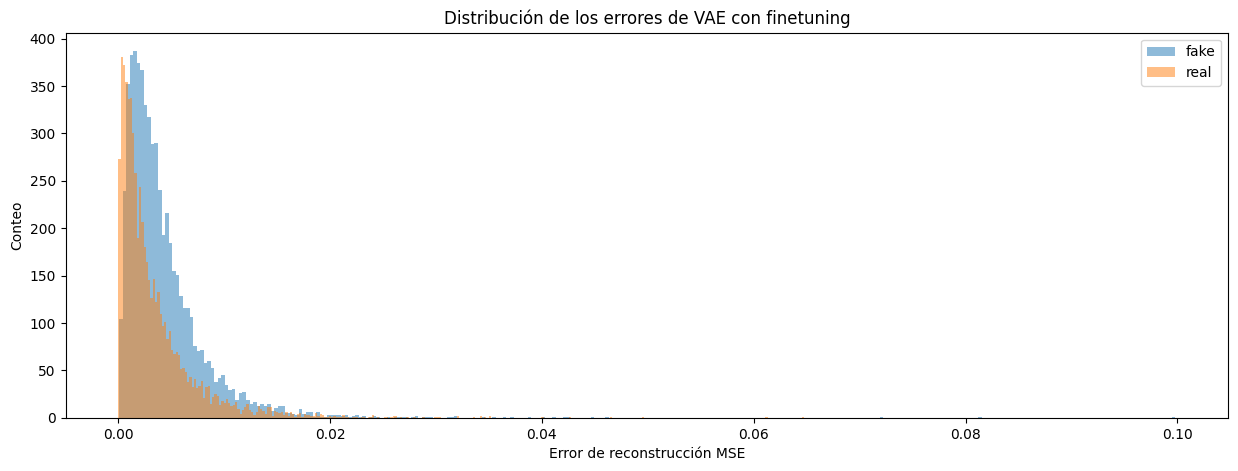

In [72]:
errores_pixel = np.array(errores_pixel)

plt.figure(figsize=(15, 5))

plt.hist(errores_pixel[y_true == 0], bins=300, alpha=0.5, label="fake")
plt.hist(errores_pixel[y_true == 1], bins=300, alpha=0.5, label="real")
plt.legend()
plt.title("Distribución de los errores de VAE con finetuning")
plt.xlabel("Error de reconstrucción MSE")
plt.ylabel("Conteo");
plt.savefig('/workspace/imagenes_metricas_vae/distribucion_errores_MSE_vae_ft_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [73]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

fake = 0
real = 1

umbral_min = np.min(errores_pixel[y_true==fake])
umbral_max = np.mean(errores_pixel[y_true==fake]) + 5*np.std(errores_pixel[y_true==fake])
print(umbral_min, umbral_max)
umbrales = np.linspace(umbral_min, umbral_max, 100)

scores = []
for umbral in umbrales:
    y_pred = [real if error < umbral else fake for error in errores_pixel]
    y_pred = np.array(y_pred)

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    macro_f1 = report['macro avg']['f1-score']
    scores.append(macro_f1)

mejor_idx = np.argmax(scores)
mejor_umbral = umbrales[mejor_idx]
mejor_f1 = scores[mejor_idx]

print(f"Mejor umbral: {mejor_umbral:.4f}")
print(f"Mejor puntaje F1: {mejor_f1:.4f}")

9.932179818861187e-05 0.026180555434872518
Mejor umbral: 0.0022
Mejor puntaje F1: 0.5882


In [74]:
fake = 0
real = 1
y_pred = [real if error < mejor_umbral else fake for error in errores_pixel]
y_pred = np.array(y_pred)

Distribución y_true: [5970 5994]
Distribución y_pred: [6912 5052]


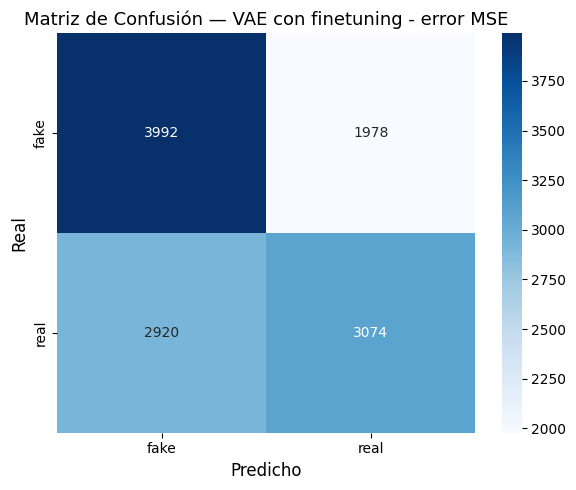


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fake       0.58      0.67      0.62      5970
        real       0.61      0.51      0.56      5994

    accuracy                           0.59     11964
   macro avg       0.59      0.59      0.59     11964
weighted avg       0.59      0.59      0.59     11964



In [ ]:
print("Distribución y_true:", np.bincount(y_true))
print("Distribución y_pred:", np.bincount(y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=etiquetas,
    yticklabels=etiquetas
)
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión — VAE con finetuning - error MSE', fontsize=13)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_vae/confusion_matrix_vae_ft_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=etiquetas))

Imagen guardada como classification_report.png


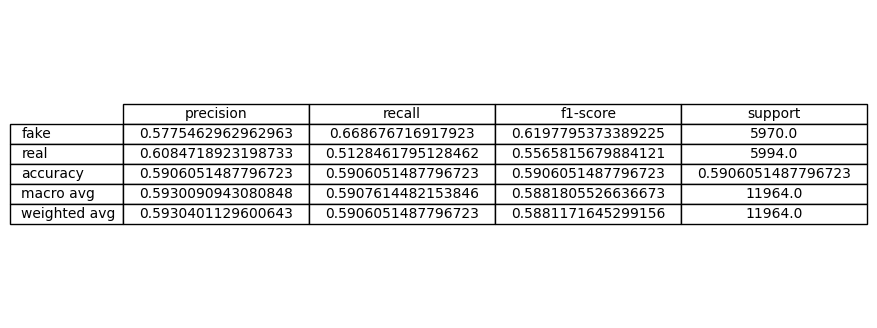

In [76]:
report_dict = classification_report(y_true, y_pred, target_names=etiquetas, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

fig, ax = plt.subplots(figsize=(8, 4)) 
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_report.values,
                 colLabels=df_report.columns,
                 rowLabels=df_report.index,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Ajustar escala

plt.savefig('/workspace/imagenes_metricas_vae/classification_report_vae_ft_final.png', bbox_inches='tight', dpi=300)
print("Imagen guardada como classification_report.png")

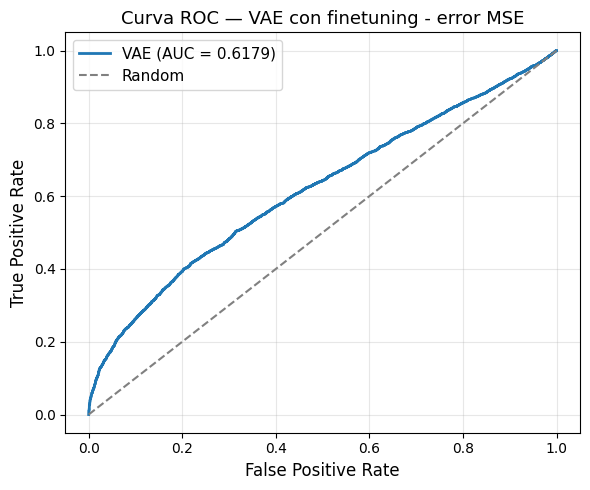

AUC final (test completo): 0.6179


In [77]:
fpr, tpr, _ = roc_curve(y_true, [-e for e in errores_pixel])
auc_score   = roc_auc_score(y_true, [-e for e in errores_pixel])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'VAE (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC — VAE con finetuning - error MSE', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/workspace/imagenes_metricas_vae/roc_curve_vae_ft_final.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC final (test completo): {auc_score:.4f}")